# Banana freshness SNN for Arduino UNO

This notebook uses only banana freshness data and the separate `no_fruit` class. Open recordings are sorted by `Ticks`, split into recording sessions, and resampled to one median observation per elapsed second. The strict evaluation trains on earlier sessions and holds out the complete final fresh and spoiled sessions.

The deployed model has one fixed rate-coded LIF neuron for each of the nine engineered features and a quantized linear readout. Its threshold is fitted only on training data at the 80th percentile of spoiled scores, reserving margin for between-session sensor drift.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp
from sklearn.metrics import balanced_accuracy_score, f1_score, recall_score
from sklearn.model_selection import GroupShuffleSplit
from freshness_tree_model import (
    FEATURES, SENSORS, OPEN_BIN_MS, calibration, even_sample, load_recording,
    load_open_resampled, last_session_split, make_features, map_custom,
    open_block_groups, open_time_windows, open_training_data,
)
from freshness_snn_model import (
    SPOILED_MARGIN_PERCENTILE, TIME_STEPS, fit_snn, model_flash_bytes, predict_snn,
)

sns.set_theme(style='whitegrid')
X_open, y_open, open_fresh = open_training_data()
open_rotten = load_open_resampled('banana_rotten.csv')
custom_fresh = load_recording('banana_fresh_custom.csv', custom=True)
custom_rotten = load_recording('banana_rotten_custom.csv', custom=True)
custom_spoil = load_recording('banana_starts_to_spoil_custom.csv', custom=True)
no_fruit = load_recording('no_fruit.csv', custom=True)
gain, offset, no_fruit_threshold, fresh_cal_end, rotten_cal_end, no_fruit_cal_end = calibration(
    open_fresh, open_rotten, custom_fresh, custom_rotten, no_fruit
)
features_open = make_features(X_open)
assert tuple(features_open.columns) == FEATURES
print('Open rows:', len(X_open), 'fresh:', int(y_open.sum()), 'spoiled:', int((1-y_open).sum()))
print('Nine inputs:', list(FEATURES))
print('Resampling interval:', OPEN_BIN_MS, 'ms per observed second')
print('Sessions: fresh', len(set(open_fresh.attrs['session_ids'])),
      'spoiled', len(set(open_rotten.attrs['session_ids'])))

Open rows: 733 fresh: 360 spoiled: 373
Nine inputs: ['MQ3_ratio_MQ135', 'MQ3_ratio_MQ5', 'MQ3_minus_MQ5', 'MQ3_minus_MQ135', 'MQ5_ratio_MQ135', 'sensor_std', 'MQ5_minus_MQ135', 'MQ5_plus_MQ135', 'MQ3']
Resampling interval: 1000 ms per observed second
Sessions: fresh 2 spoiled 3


## Custom-to-open sensor calibration

The first 20% of the custom fresh and custom spoiled recordings supplies two class anchors for a per-sensor affine mapping: `open = custom × gain + offset`. All remaining fresh and spoiled samples are held out. The raw custom MQ3 range supplies the separate no-fruit gate before mapping.

,open fresh median,open spoiled median,custom fresh calibration median,custom spoiled calibration median,affine gain,affine offset,held-out mapped fresh median,held-out mapped spoiled median
MQ3,105.0,284.0,89.0,812.85,0.247,82.991,105.705,287.029
MQ5,540.0,1075.0,846.0,93.00,-0.710,1141.076,533.108,1074.787
MQ135,33.0,168.0,68.0,81.15,10.266,-665.099,58.665,163.380


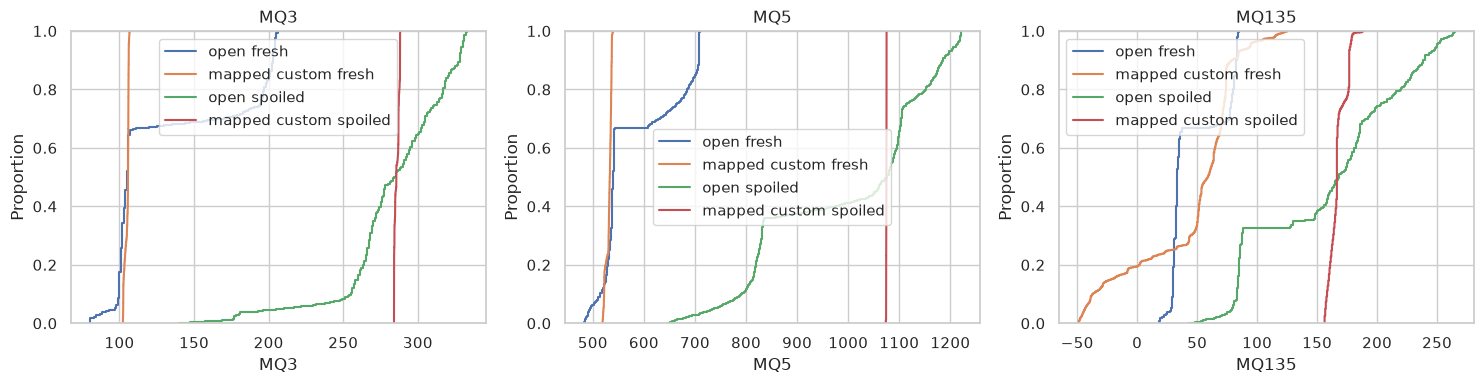

,MQ3,MQ5,MQ135
class,,,
fresh,0.356,0.611,0.404
spoiled,0.500,0.499,0.411


Raw no-fruit MQ3 threshold: 68.375


In [2]:
def mapped(frame):
    return map_custom(frame, gain, offset)

custom_fresh_test = custom_fresh.iloc[fresh_cal_end:]
custom_rotten_test = custom_rotten.iloc[rotten_cal_end:]
no_fruit_test = no_fruit.iloc[no_fruit_cal_end:]
comparison = pd.DataFrame({
    'open fresh median': open_fresh.median(),
    'open spoiled median': open_rotten.median(),
    'custom fresh calibration median': custom_fresh.iloc[:fresh_cal_end].median(),
    'custom spoiled calibration median': custom_rotten.iloc[:rotten_cal_end].median(),
    'affine gain': gain,
    'affine offset': offset,
    'held-out mapped fresh median': mapped(custom_fresh_test).median(),
    'held-out mapped spoiled median': mapped(custom_rotten_test).median(),
})
display(comparison.round(3))
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, sensor in zip(axes, SENSORS):
    for label, frame in [('open fresh', open_fresh),
                         ('mapped custom fresh', mapped(custom_fresh_test)),
                         ('open spoiled', open_rotten),
                         ('mapped custom spoiled', mapped(custom_rotten_test))]:
        sns.ecdfplot(even_sample(frame, 3000)[sensor], ax=ax, label=label)
    ax.set_title(sensor); ax.legend()
plt.tight_layout(); plt.show()
ks_rows = []
for label, custom, opened in [('fresh', custom_fresh_test, open_fresh),
                              ('spoiled', custom_rotten_test, open_rotten)]:
    ks_rows.append({'class': label, **{
        sensor: ks_2samp(even_sample(opened, 3000)[sensor],
                         even_sample(mapped(custom), 3000)[sensor]).statistic
        for sensor in SENSORS}})
display(pd.DataFrame(ks_rows).set_index('class').round(3))
print('Raw no-fruit MQ3 threshold:', round(no_fruit_threshold, 3))

## Quantized SNN evaluation

Balanced accuracy is the primary metric because it weights fresh and spoiled recall equally. Blocked splits measure local interpolation. Elapsed-time windows and complete-session folds measure transfer across sensor drift. Within each fold, the held-out recording contributes no rows to normalization, weights, or threshold fitting.

In [3]:
window_rows = []
for window, (train_idx, test_idx) in enumerate(open_time_windows(y_open)):
    model = fit_snn(features_open.iloc[train_idx], y_open[train_idx])
    predicted = predict_snn(model, X_open.iloc[test_idx])
    window_rows.append({
        'window': window,
        'balanced accuracy': balanced_accuracy_score(y_open[test_idx], predicted),
        'macro F1': f1_score(y_open[test_idx], predicted, average='macro'),
        'spoiled recall': recall_score(y_open[test_idx], predicted, pos_label=0),
    })
window_results = pd.DataFrame(window_rows)
display(window_results.round(4))
print('Mean window balanced accuracy:', round(window_results['balanced accuracy'].mean(), 4))

groups = open_block_groups(X_open, y_open)
blocked_rows = []
for train_idx, test_idx in GroupShuffleSplit(n_splits=5, test_size=.2, random_state=42).split(
        X_open, y_open, groups):
    model = fit_snn(features_open.iloc[train_idx], y_open[train_idx])
    predicted = predict_snn(model, X_open.iloc[test_idx])
    blocked_rows.append(balanced_accuracy_score(y_open[test_idx], predicted))
print('Blocked balanced accuracy mean/worst:',
      round(float(np.mean(blocked_rows)), 4), round(float(np.min(blocked_rows)), 4))

,window,balanced accuracy,macro F1,spoiled recall
0,0,0.5000,0.3288,0.0000
1,1,0.7667,0.7501,0.5333
2,2,1.0000,1.0000,1.0000
3,3,0.9932,0.9932,0.9865
4,4,1.0000,1.0000,1.0000


Mean window balanced accuracy: 0.852
Blocked balanced accuracy mean/worst: 0.9525 0.879


In [4]:
# Hold out every complete recording session once and pool all out-of-session predictions.
session_ids = np.asarray(X_open.attrs['session_ids'])
session_cv_predicted = np.empty_like(y_open)
session_rows = []
for label in (1, 0):
    for session in sorted(set(session_ids[y_open == label])):
        test_idx = np.flatnonzero((y_open == label) & (session_ids == session))
        train_idx = np.setdiff1d(np.arange(len(y_open)), test_idx)
        model = fit_snn(features_open.iloc[train_idx], y_open[train_idx])
        predicted = predict_snn(model, X_open.iloc[test_idx])
        session_cv_predicted[test_idx] = predicted
        session_rows.append({'class': 'fresh' if label else 'spoiled',
                             'session': int(session), 'rows': len(test_idx),
                             'accuracy': float(np.mean(predicted == y_open[test_idx]))})
display(pd.DataFrame(session_rows).round(4))
print('Pooled leave-one-session-out balanced accuracy:',
      round(balanced_accuracy_score(y_open, session_cv_predicted), 4))
print('Pooled fresh/spoiled recall:',
      round(recall_score(y_open, session_cv_predicted, pos_label=1), 4),
      round(recall_score(y_open, session_cv_predicted, pos_label=0), 4))

,class,session,rows,accuracy
0,fresh,0,241,1.0000
1,fresh,1,119,1.0000
2,spoiled,0,122,0.0000
3,spoiled,1,122,0.8525
4,spoiled,2,129,1.0000


Pooled leave-one-session-out balanced accuracy: 0.8123
Pooled fresh/spoiled recall: 1.0 0.6247


In [5]:
session_train, session_test = last_session_split(X_open, y_open)
session_model = fit_snn(features_open.iloc[session_train], y_open[session_train])
session_predicted = predict_snn(session_model, X_open.iloc[session_test])
session_result = pd.DataFrame({
    'metric': ['balanced accuracy', 'macro F1', 'fresh recall', 'spoiled recall'],
    'value': [
        balanced_accuracy_score(y_open[session_test], session_predicted),
        f1_score(y_open[session_test], session_predicted, average='macro'),
        recall_score(y_open[session_test], session_predicted, pos_label=1),
        recall_score(y_open[session_test], session_predicted, pos_label=0),
    ]
})
print('Final-session chronological validation rows:', len(session_test),
      'fresh:', int(np.sum(y_open[session_test] == 1)),
      'spoiled:', int(np.sum(y_open[session_test] == 0)))
display(session_result.set_index('metric').round(4))
print('Training-only drift threshold: spoiled score percentile', SPOILED_MARGIN_PERCENTILE)

Final-session chronological validation rows: 248 fresh: 119 spoiled: 129


,value
metric,
balanced accuracy,1.0
macro F1,1.0
fresh recall,1.0
spoiled recall,1.0


Training-only drift threshold: spoiled score percentile 80


## Final deployable model and custom recordings

The model uses all nine engineered features. `banana_starts_to_spoil_custom.csv` remains a diagnostic recording with no forced ground-truth freshness label.

In [6]:
final_snn = fit_snn(features_open, y_open)
print('Architecture:', len(FEATURES), 'rate-coded LIF neurons ×', TIME_STEPS, 'steps')
print('Quantized model bytes:', model_flash_bytes(final_snn))
print('Nonzero readout for every input:',
      dict(zip(FEATURES, (final_snn.readout != 0).tolist())))
print('Open fitted balanced accuracy (fit check only):',
      round(balanced_accuracy_score(y_open, predict_snn(final_snn, X_open)), 4))

recordings = {
    'held-out custom fresh': (custom_fresh_test, 1),
    'held-out custom spoiled': (custom_rotten_test, 0),
    'held-out no fruit': (no_fruit_test, 2),
    'starts to spoil (diagnostic)': (custom_spoil, None),
}
rows = []
for name, (frame, target) in recordings.items():
    predicted = predict_snn(final_snn, mapped(frame),
                            no_fruit_threshold=no_fruit_threshold,
                            raw_values=frame)
    fractions = pd.Series(predicted).value_counts(normalize=True)
    rows.append({
        'recording': name, 'rows': len(frame),
        'known-label accuracy': float(np.mean(predicted == target)) if target is not None else np.nan,
        'predicted NO_FRUIT': fractions.get(2, 0.0),
        'predicted FRESH': fractions.get(1, 0.0),
        'predicted SPOILED': fractions.get(0, 0.0),
    })
display(pd.DataFrame(rows).set_index('recording').round(5))

Architecture: 9 rate-coded LIF neurons × 8 steps
Quantized model bytes: 94
Nonzero readout for every input: {'MQ3_ratio_MQ135': True, 'MQ3_ratio_MQ5': True, 'MQ3_minus_MQ5': True, 'MQ3_minus_MQ135': True, 'MQ5_ratio_MQ135': True, 'sensor_std': True, 'MQ5_minus_MQ135': True, 'MQ5_plus_MQ135': True, 'MQ3': True}
Open fitted balanced accuracy (fit check only): 0.8767


,rows,known-label accuracy,predicted NO_FRUIT,predicted FRESH,predicted SPOILED
recording,,,,,
held-out custom fresh,48197,1.0,0.0,1.0,0.0
held-out custom spoiled,4630,1.0,0.0,0.0,1.0
held-out no fruit,2485,1.0,1.0,0.0,0.0
starts to spoil (diagnostic),130787,NaN,0.0,1.0,0.0
